# Results Reporting

Unified reporting notebook. Parses executed notebooks (`churn.ipynb`, `gmsc.ipynb`, `upsell.ipynb`) and produces:

1. **Per-dataset performance tables** (AEC + AUROC, sorted by AEC)
2. **Cross-dataset summary table** with mean ranks
3. **Pareto scatter plots** (AEC vs AUROC per dataset)
4. **Hyperparameter selection analysis** (γ, α, β, λ across folds)
5. **Friedman + Nemenyi significance testing** (cross-dataset)
6. **Per-dataset Friedman + Nemenyi** (across folds)
7. **Rank bar charts + win-rate heatmaps**

**Persistence:** A **kernel restart** only clears RAM. This notebook reads **saved outputs inside each `.ipynb` file** (and optional `results/summary_*.csv`). If you see tables in the UI but parsing fails, use **File → Save Notebook** so outputs are written to disk, set **`EXPERIMENT_REPO`** to the project folder if Jupyter’s working directory is wrong, or re-run this cell after the fix (no full retrain needed).

**Requirement:** Experiment notebooks should contain the summary `display` output (HTML and/or plain text). If that output was cleared from the file, restore from git/backup or use CSVs from a previous export.

In [1]:
import json
import os
import re
import warnings
from io import StringIO
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import friedmanchisquare, studentized_range, wilcoxon, rankdata

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)

# Report-oriented figure defaults (tight layout still recommended per figure)
REPORT_SAVEFIG_DPI = 300
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': REPORT_SAVEFIG_DPI,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'lines.linewidth': 1.5,
})


def find_repo_root() -> Path:
    env = os.environ.get('EXPERIMENT_REPO', '').strip()
    if env:
        p = Path(env).expanduser().resolve()
        if (p / 'churn.ipynb').is_file():
            return p
    cwd = Path.cwd().resolve()
    for anchor in ('churn.ipynb', 'gmsc.ipynb'):
        for p in [cwd, *cwd.parents]:
            if (p / anchor).is_file():
                return p
    return cwd


REPO_ROOT = find_repo_root()

NOTEBOOK_PATHS = {
    'Churn': REPO_ROOT / 'churn.ipynb',
    'GMSC': REPO_ROOT / 'gmsc.ipynb',
    'Upsell': REPO_ROOT / 'upsell.ipynb',
}

CANONICAL_ORDER = [
    'logit', 'cslogit', 'boost', 'csboost',
    'layer_proba_safe', 'weighted_xgb_aec', 'costloss_xgb',
    'transfer_xgb', 'curriculum_xgb',
    'teacher_csboost',
]

# Dropped from every table, export, and figure in this notebook (still in experiment .ipynb files)
REPORT_DROP_MODELS = frozenset({'transfer_xgb_fullcs', 'hybrid_aug_xgb'})


def pareto_non_dominated_mask(auroc_vals, aec_vals):
    """Non-dominated points for maximize AUROC, minimize AEC."""
    au = np.asarray(auroc_vals, dtype=float)
    ae = np.asarray(aec_vals, dtype=float)
    n = len(au)
    mask = np.zeros(n, dtype=bool)
    for i in range(n):
        dominated = False
        for j in range(n):
            if i == j:
                continue
            if (au[j] >= au[i] and ae[j] <= ae[i]) and (au[j] > au[i] or ae[j] < ae[i]):
                dominated = True
                break
        mask[i] = not dominated
    return mask


def pareto_non_dominated_mask_minimize_both(x_vals, y_vals):
    """Non-dominated when both coordinates are lower-is-better (e.g. mean ranks)."""
    x = np.asarray(x_vals, dtype=float)
    y = np.asarray(y_vals, dtype=float)
    n = len(x)
    mask = np.zeros(n, dtype=bool)
    for i in range(n):
        dominated = False
        for j in range(n):
            if i == j:
                continue
            if (x[j] <= x[i] and y[j] <= y[i]) and (x[j] < x[i] or y[j] < y[i]):
                dominated = True
                break
        mask[i] = not dominated
    return mask


BASELINES = {'logit', 'cslogit', 'boost', 'csboost'}
PROPOSED = set(CANONICAL_ORDER) - BASELINES

GROUP_LABELS = {
    'logit': 'Baseline', 'cslogit': 'Baseline', 'boost': 'Baseline', 'csboost': 'Baseline',
    'layer_proba_safe': 'Layered', 'teacher_csboost': 'Layered',
    'weighted_xgb_aec': 'Weighted',
    'costloss_xgb': 'Loss shaping',
    'transfer_xgb': 'Sequential', 'curriculum_xgb': 'Sequential',
}

GROUP_COLORS = {
    'Baseline': '#95a5a6', 'Layered': '#3498db',
    'Weighted': '#e67e22', 'Loss shaping': '#e74c3c', 'Sequential': '#2ecc71',
}

ALPHA = 0.05
print(f'Repo root: {REPO_ROOT}')

Repo root: /Users/lea/final cost sensitive 


## 0. Parse notebook outputs

In [2]:
def _join_mime(data: dict, key: str):
    raw = data.get(key)
    if not raw:
        return None
    return ''.join(raw) if isinstance(raw, list) else raw


def _read_html_tables(html: str):
    """Try several HTML parsers — lxml is optional."""
    for flavor in ('lxml', 'bs4', 'html5lib', None):
        try:
            dfs = pd.read_html(StringIO(html), flavor=flavor)
            if dfs:
                return list(dfs)
        except (ImportError, ValueError, OSError, TypeError):
            continue
    return []


def _normalize_summary_df(tbl: pd.DataFrame):
    """Wide summary: model index + metric columns including AEC_mean, AUROC_mean."""
    if tbl is None or len(tbl) < 2:
        return None
    t = tbl.copy()
    cols = t.columns
    flat = [c[0] if isinstance(c, tuple) else c for c in cols]
    if 'AEC_mean' not in flat or 'AUROC_mean' not in flat:
        return None
    if isinstance(cols, pd.MultiIndex):
        rename = {c: (c[0] if isinstance(c, tuple) else c) for c in t.columns}
        t = t.rename(columns=rename)
        t.columns = [c[0] if isinstance(c, tuple) else c for c in t.columns]
    c0 = str(t.columns[0])
    if c0 in ('Model', 'model') or c0.startswith('Unnamed'):
        t = t.set_index(t.columns[0])
    elif t.index.name == 'Model' or (len(t.index) and str(t.index[0]) not in ('0', '1', '2')):
        pass
    else:
        return None
    t.index = t.index.astype(str)
    t.index.name = 'Model'
    for c in t.columns:
        t[c] = pd.to_numeric(t[c], errors='coerce')
    t = t.loc[~t.index.str.startswith('Model')]
    return t


def _parse_aec_block_plain(plain: str):
    if 'AEC_mean' not in plain or 'Brier_mean' not in plain:
        return None
    best = None
    for block in plain.strip().split('\n\n'):
        lines = [ln.rstrip() for ln in block.splitlines() if ln.strip()]
        if not lines:
            continue
        head = lines[0]
        if 'AEC_mean' not in head or 'Brier_mean' not in head or 'train_AEC_mean' in head:
            continue
        rows = []
        for ln in lines[1:]:
            parts = ln.split()
            if len(parts) < 2 or parts[0] == 'Model':
                continue
            try:
                aec = float(parts[1])
            except ValueError:
                continue
            if not re.match(r'^[A-Za-z]', parts[0]):
                continue
            rows.append((parts[0], aec))
        if len(rows) >= 2:
            s = pd.Series({m: v for m, v in rows}, name='AEC_mean')
            if best is None or len(s) > len(best):
                best = s
    return best


def _parse_auroc_from_plain(plain: str) -> dict:
    out = {}
    for block in plain.strip().split('\n\n'):
        lines = [ln.rstrip() for ln in block.splitlines() if ln.strip()]
        if not lines:
            continue
        head = lines[0]
        if 'AUROC_mean' not in head:
            continue
        hdr = head.split()
        if 'AUROC_mean' not in hdr:
            continue
        i_auc = hdr.index('AUROC_mean')
        for ln in lines[1:]:
            parts = ln.split()
            if len(parts) < 2 + i_auc or parts[0] == 'Model':
                continue
            try:
                out[parts[0]] = float(parts[1 + i_auc])
            except (ValueError, IndexError):
                continue
    return out


def _metrics_from_plain(plain: str):
    if 'AUROC_mean' not in plain:
        return None
    aec = _parse_aec_block_plain(plain)
    if aec is None or len(aec) < 2:
        return None
    auc_map = _parse_auroc_from_plain(plain)
    common = sorted(set(aec.index) & set(auc_map.keys()))
    if len(common) < 2:
        return None
    return pd.DataFrame(
        {'AEC_mean': aec.loc[common].values, 'AUROC_mean': [auc_map[m] for m in common]},
        index=common,
    )


def _extract_summary_candidates(nb: dict):
    candidates = []
    for cell in nb.get('cells', []):
        if cell.get('cell_type') != 'code':
            continue
        for out in cell.get('outputs', []):
            if out.get('output_type') not in ('display_data', 'execute_result'):
                continue
            data = out.get('data', {}) or {}
            plain = _join_mime(data, 'text/plain')
            if plain and 'AEC_mean' in plain and 'AUROC_mean' in plain:
                t = _metrics_from_plain(plain)
                if t is not None and len(t) >= 2:
                    candidates.append(('plain', t))
            html = _join_mime(data, 'text/html')
            if not html or 'AEC_mean' not in html:
                continue
            for tbl in _read_html_tables(html):
                t = _normalize_summary_df(tbl)
                if t is not None and len(t) >= 2:
                    candidates.append(('html', t))
    return candidates


def _load_summary_csv(nb_path: Path):
    slug = nb_path.stem.lower()
    p = REPO_ROOT / 'results' / f'summary_{slug}.csv'
    if not p.is_file():
        return None
    try:
        df = pd.read_csv(p, index_col=0)
        if 'AEC_mean' in df.columns and 'AUROC_mean' in df.columns:
            df.index.name = 'Model'
            return df.apply(pd.to_numeric, errors='coerce')
    except Exception:
        return None
    return None


def parse_notebook_results(nb_path):
    """Extract the summary results table from saved notebook outputs (HTML and/or plain)."""
    nb_path = Path(nb_path)
    with open(nb_path, encoding='utf-8') as f:
        nb = json.load(f)

    cands = _extract_summary_candidates(nb)
    if cands:
        best = max(cands, key=lambda x: (x[1].shape[1], x[1].shape[0]))[1]
        best.index.name = 'Model'
        return best

    csv_df = _load_summary_csv(nb_path)
    if csv_df is not None:
        return csv_df

    raise ValueError(
        f'No AEC_mean+AUROC_mean summary in {nb_path.name}. '
        'Save the experiment notebook with outputs, set EXPERIMENT_REPO, or add results/summary_{stem}.csv'
    )


def parse_fold_results(nb_path):
    """Extract fold-level table from notebook outputs (largest HTML table with SplitID)."""
    with open(nb_path, encoding='utf-8') as f:
        nb = json.load(f)

    best_tbl = None
    best_n = 0
    for cell in nb.get('cells', []):
        if cell.get('cell_type') != 'code':
            continue
        src = ''.join(cell.get('source', []))
        if 'fold_df' not in src:
            continue
        for out in cell.get('outputs', []):
            if out.get('output_type') not in ('display_data', 'execute_result'):
                continue
            data = out.get('data', {}) or {}
            html = _join_mime(data, 'text/html')
            if not html or 'AEC' not in html or 'Model' not in html:
                continue
            for tbl in _read_html_tables(html):
                cols = [c[0] if isinstance(c, tuple) else c for c in tbl.columns]
                if 'Model' not in cols or 'AEC' not in cols or 'SplitID' not in cols:
                    continue
                if len(tbl) > best_n:
                    best_n = len(tbl)
                    best_tbl = tbl
    return best_tbl


def load_fold_long_csv(nb_path):
    stem = Path(nb_path).stem.lower()
    p = REPO_ROOT / 'results' / f'fold_long_{stem}.csv'
    if not p.is_file():
        return None
    try:
        return pd.read_csv(p)
    except Exception:
        return None


def normalize_fold_long_df(df):
    if df is None or len(df) == 0:
        return None
    out = df.copy()
    for c in list(out.columns):
        if str(c).startswith('Unnamed'):
            out = out.drop(columns=[c], errors='ignore')
    for col in ('SplitID', 'Model', 'AEC', 'AUROC'):
        if col not in out.columns:
            return None
    return out


def get_fold_long_df(nb_path):
    """Prefer results/fold_long_{stem}.csv (written when experiment build cell runs); else largest embedded table."""
    candidates = []
    a = load_fold_long_csv(nb_path)
    if a is not None:
        candidates.append(a)
    b = parse_fold_results(nb_path)
    if b is not None:
        candidates.append(b)
    if not candidates:
        return None
    best = max(candidates, key=lambda d: len(d))
    return normalize_fold_long_df(best)


all_summaries = {}
all_folds = {}
for ds_name, nb_path in NOTEBOOK_PATHS.items():
    if not nb_path.exists():
        print(f'WARNING: {nb_path.name} not found, skipping {ds_name}')
        continue
    try:
        all_summaries[ds_name] = parse_notebook_results(nb_path)
        print(f'{ds_name}: {len(all_summaries[ds_name])} models loaded')
    except Exception as e:
        print(f'WARNING: Could not parse {ds_name}: {e}')
    fold_raw = get_fold_long_df(nb_path)
    if fold_raw is not None:
        all_folds[ds_name] = fold_raw
        ns = fold_raw['SplitID'].nunique()
        print(f'  fold-long: {len(fold_raw)} rows, {ns} distinct SplitID (Wilcoxon: re-export results/fold_long_{nb_path.stem.lower()}.csv)')
    else:
        print(f'  fold-long: none (re-run experiment fold_df cell to write results/fold_long_{nb_path.stem.lower()}.csv)')

# Remove models omitted from this report (tables + all downstream plots)
for _ds in list(all_summaries.keys()):
    df = all_summaries[_ds]
    drops = [m for m in REPORT_DROP_MODELS if m in df.index]
    if drops:
        all_summaries[_ds] = df.drop(index=drops)
for _ds in list(all_folds.keys()):
    fdf = all_folds[_ds]
    if fdf is not None and 'Model' in fdf.columns:
        all_folds[_ds] = fdf[~fdf['Model'].astype(str).isin(REPORT_DROP_MODELS)].copy().reset_index(drop=True)

print(f'\nDatasets loaded: {list(all_summaries.keys())}')

Churn: 12 models loaded
  fold-long: 5 rows, 5 distinct SplitID (Wilcoxon: re-export results/fold_long_churn.csv)
GMSC: 12 models loaded
  fold-long: 5 rows, 5 distinct SplitID (Wilcoxon: re-export results/fold_long_gmsc.csv)
Upsell: 12 models loaded
  fold-long: 5 rows, 5 distinct SplitID (Wilcoxon: re-export results/fold_long_upsell.csv)

Datasets loaded: ['Churn', 'GMSC', 'Upsell']


---
## 1. Per-dataset performance tables

In [3]:
display_cols = ['AEC_mean', 'AEC_std', 'AUROC_mean', 'AUROC_std',
                'Cost_mean', 'Savings_no_action_mean', 'Brier_mean',
                'AP_mean', 'F1_mean', 'fit_time_mean']

for ds_name, df in all_summaries.items():
    available = [c for c in display_cols if c in df.columns]
    print(f'\n{"=" * 60}')
    print(f'  {ds_name} — Performance summary (sorted by AEC, lower = better)')
    print(f'{"=" * 60}')
    ordered = [m for m in CANONICAL_ORDER if m in df.index]
    extras = [m for m in df.index if m not in CANONICAL_ORDER]
    display(df.loc[ordered + extras, available].sort_values('AEC_mean').round(4))


  Churn — Performance summary (sorted by AEC, lower = better)


,AEC_mean,AUROC_mean,Cost_mean,Savings_no_action_mean,Brier_mean,AP_mean,F1_mean,fit_time_mean
Model,,,,,,,,
csboost,50.6739,0.7052,97357.0022,0.1370,0.2224,0.1065,0.1435,51.0655
teacher_csboost,51.1578,0.7040,95178.3614,0.1560,0.2593,0.0977,0.1570,14.4618
curriculum_xgb,58.0131,0.6709,109863.8374,0.0252,0.0908,0.0894,0.1280,63.8836
cslogit,58.2051,0.5812,109932.0874,0.0262,0.1455,0.0723,0.1200,41.1086
weighted_xgb_aec,58.5527,0.6745,102652.4654,0.0894,0.0672,0.0914,0.1433,28.8111
transfer_xgb,58.6656,0.6878,106775.1002,0.0532,0.0736,0.0953,0.1359,29.1597
costloss_xgb,58.9072,0.6755,103653.8320,0.0806,0.0598,0.0905,0.1433,56.5000
boost,59.7280,0.7210,91966.0754,0.1850,0.0444,0.1081,0.1622,22.2049
layer_proba_safe,60.1436,0.5488,112817.1429,0.0000,0.0479,0.0551,0.0000,5.3764



  GMSC — Performance summary (sorted by AEC, lower = better)


,AEC_mean,AUROC_mean,Cost_mean,Savings_no_action_mean,Brier_mean,AP_mean,F1_mean,fit_time_mean
Model,,,,,,,,
teacher_csboost,359.1374,0.8419,8.129224e+06,0.5145,0.1865,0.3116,0.3078,31.0607
csboost,368.4347,0.8448,8.318853e+06,0.5032,0.1646,0.3540,0.2872,102.9070
cslogit,393.2929,0.8044,8.823972e+06,0.4731,0.1750,0.3257,0.2992,16.5186
costloss_xgb,482.6259,0.8429,1.498134e+07,0.1054,0.1242,0.3613,0.1508,183.0374
weighted_xgb_aec,483.1361,0.8441,1.531678e+07,0.0853,0.1253,0.3629,0.1481,113.1003
curriculum_xgb,484.4415,0.8449,1.597137e+07,0.0463,0.1355,0.3659,0.1429,190.5188
transfer_xgb,486.9188,0.8458,1.624303e+07,0.0301,0.1376,0.3673,0.1410,101.0061
boost,605.3061,0.8561,8.040786e+06,0.5198,0.0501,0.3881,0.3277,50.6508
logit,716.7994,0.7058,1.293644e+07,0.2275,0.0593,0.2087,0.1789,843.1233



  Upsell — Performance summary (sorted by AEC, lower = better)


,AEC_mean,AUROC_mean,Cost_mean,Savings_no_action_mean,Brier_mean,AP_mean,F1_mean,fit_time_mean
Model,,,,,,,,
teacher_csboost,0.5098,0.6679,3875.4139,0.6733,0.2824,0.2406,0.2853,20.7274
csboost,0.5144,0.6634,3877.6203,0.6732,0.2755,0.2448,0.2749,70.0403
layer_proba_safe,0.5808,0.5719,4226.8418,0.6438,0.2903,0.1508,0.2337,8.3097
costloss_xgb,0.6947,0.6863,4458.5106,0.6242,0.2101,0.2876,0.2630,115.4426
curriculum_xgb,0.7014,0.6891,4450.4275,0.6249,0.2073,0.2896,0.2634,91.9953
transfer_xgb,0.7035,0.6892,4443.7798,0.6254,0.2076,0.2909,0.2630,60.3850
weighted_xgb_aec,0.7045,0.6869,4461.0427,0.6240,0.2085,0.2900,0.2627,76.7336
cslogit,0.8027,0.6735,4788.2141,0.5964,0.2393,0.2116,0.2550,40.6267
boost,1.2558,0.7362,3815.5464,0.6784,0.0940,0.3840,0.2914,44.2212


---
## 1b. Pairwise Wilcoxon vs baselines (AEC & AUROC)

Paired **Wilcoxon signed-rank** tests across outer CV splits (`SplitID`), **Holm–Bonferroni** adjusted *p*-values over all target×baseline pairs for that metric on that dataset. Targets = all models in `CANONICAL_ORDER` that are not baselines and appear in `fold_df`. Baselines = `logit`, `cslogit`, `boost`, `csboost`.

**Data:** requires a long fold table with columns `SplitID`, `Model`, `AEC`, `AUROC`. After you re-run the **build `fold_df`** cell in each experiment notebook, `results/fold_long_{churn,gmsc,upsell}.csv` is written automatically.

In [4]:
WILCOXON_BASELINES = ['logit', 'cslogit', 'boost', 'csboost']
WILCOXON_ALPHA_PRIMARY = 0.05
WILCOXON_ALPHA_SECONDARY = 0.10
MIN_UNIQUE_SPLITS = 3  # paired Wilcoxon across SplitID


def holm_bonferroni_wilcox(p_values):
    n = len(p_values)
    order = np.argsort(p_values)
    adjusted = np.ones(n, dtype=float)
    cummax = 0.0
    for rank, idx in enumerate(order):
        corrected = p_values[idx] * (n - rank)
        cummax = max(cummax, corrected)
        adjusted[idx] = min(cummax, 1.0)
    return adjusted


def wilcoxon_sig_marker(p):
    if p < WILCOXON_ALPHA_PRIMARY:
        return '**'
    if p < WILCOXON_ALPHA_SECONDARY:
        return '*'
    return ''


def rank_biserial_correlation(x, y):
    diff = np.asarray(x, dtype=float) - np.asarray(y, dtype=float)
    diff = diff[diff != 0]
    if len(diff) == 0:
        return 0.0
    abs_diff = np.abs(diff)
    ranks = rankdata(abs_diff)
    r_plus = np.sum(ranks[diff > 0])
    r_minus = np.sum(ranks[diff < 0])
    denom = r_plus + r_minus
    return float((r_plus - r_minus) / denom) if denom > 0 else 0.0


def pairwise_wilcoxon_vs_baselines(fold_df, target_models, baseline_models, metric):
    pivot = fold_df.pivot_table(index='SplitID', columns='Model', values=metric, aggfunc='first')
    rows = []
    lower_is_better = metric in ('AEC', 'Cost', 'Brier')
    for target in target_models:
        if target not in pivot.columns:
            continue
        for baseline in baseline_models:
            if baseline not in pivot.columns:
                continue
            paired = pivot[[target, baseline]].dropna()
            x = paired[target].values.astype(float)
            y = paired[baseline].values.astype(float)
            try:
                stat, p_value = wilcoxon(x, y, zero_method='wilcox', alternative='two-sided')
                stat = float(stat)
                p_value = float(p_value)
            except ValueError:
                stat = np.nan
                p_value = 1.0
            target_mean = float(np.mean(x))
            baseline_mean = float(np.mean(y))
            mean_diff = target_mean - baseline_mean
            better = mean_diff < 0 if lower_is_better else mean_diff > 0
            r_rb = rank_biserial_correlation(x, y)
            rows.append({
                'metric': metric,
                'target': target,
                'baseline': baseline,
                'target_mean': target_mean,
                'baseline_mean': baseline_mean,
                'mean_diff': mean_diff,
                'wilcoxon_stat': stat,
                'p_value': p_value,
                'effect_size_r': r_rb,
                'better_than_baseline': better,
            })
    result_df = pd.DataFrame(rows)
    if len(result_df) == 0:
        return result_df
    result_df['p_adjusted'] = holm_bonferroni_wilcox(result_df['p_value'].values)
    result_df['sig_marker'] = result_df['p_adjusted'].apply(wilcoxon_sig_marker)

    def _result_row(r):
        m = r['sig_marker']
        if m:
            return (f"{m} better" if r['better_than_baseline'] else f"{m} worse")
        return 'n.s.'

    result_df['result'] = result_df.apply(_result_row, axis=1)
    return result_df


wilcoxon_display_cols = [
    'target', 'baseline', 'target_mean', 'baseline_mean', 'mean_diff',
    'effect_size_r', 'p_value', 'p_adjusted', 'result',
]

for ds_name in all_summaries.keys():
    print(f'\n{"=" * 72}\n  {ds_name} — Wilcoxon vs baselines (AEC & AUROC)\n{"=" * 72}')
    nb_path = NOTEBOOK_PATHS.get(ds_name)
    if nb_path is not None:
        print(f'  Source: {nb_path.resolve()}')
    fold_df = all_folds.get(ds_name)
    if fold_df is None:
        print('  Skipped: no fold-long table. Re-run the experiment cell that builds fold_df '
              f'(writes results/fold_long_{nb_path.stem.lower() if nb_path else "?"}.csv).')
        continue
    n_split = fold_df['SplitID'].nunique()
    if n_split < MIN_UNIQUE_SPLITS:
        print(
            f'  Skipped: need ≥{MIN_UNIQUE_SPLITS} distinct SplitID for paired tests '
            f'(got {n_split}; embedded notebook preview is often only fold_df.head()). '
            f'Re-run the fold_df build cell so results/fold_long_{nb_path.stem.lower()}.csv is written.'
        )
        continue
    cols = set(fold_df.columns)
    if not {'SplitID', 'Model', 'AEC', 'AUROC'}.issubset(cols):
        print('  Skipped: fold_df missing SplitID / Model / AEC / AUROC columns.')
        continue
    present = set(fold_df['Model'].astype(str).unique())
    targets = [m for m in CANONICAL_ORDER if m not in WILCOXON_BASELINES and m in present]
    baselines = [m for m in WILCOXON_BASELINES if m in present]
    if len(targets) == 0 or len(baselines) == 0:
        print('  Skipped: no targets or baselines present in fold_df.')
        continue
    for metric, label in [('AEC', 'AEC (lower is better)'), ('AUROC', 'AUROC / AUC (higher is better)')]:
        wdf = pairwise_wilcoxon_vs_baselines(fold_df, targets, baselines, metric)
        print(f'\n  --- {label} ---')
        if len(wdf) == 0:
            print('  (no comparisons)')
            continue
        display(wdf.sort_values(['target', 'baseline'])[wilcoxon_display_cols].round(4))



  Churn — Wilcoxon vs baselines (AEC & AUROC)
  Source: /Users/lea/final cost sensitive /churn.ipynb
  Skipped: no targets or baselines present in fold_df.

  GMSC — Wilcoxon vs baselines (AEC & AUROC)
  Source: /Users/lea/final cost sensitive /gmsc.ipynb
  Skipped: no targets or baselines present in fold_df.

  Upsell — Wilcoxon vs baselines (AEC & AUROC)
  Source: /Users/lea/final cost sensitive /upsell.ipynb
  Skipped: no targets or baselines present in fold_df.


---
## 2. Cross-dataset summary: AEC and AUROC

In [5]:
common_models = None
for ds_name, df in all_summaries.items():
    models = set(df.index)
    common_models = models if common_models is None else common_models & models

common_models = [m for m in CANONICAL_ORDER if m in common_models] + \
                sorted([m for m in common_models if m not in CANONICAL_ORDER])
print(f'Models present in all datasets ({len(common_models)}): {common_models}')

M_aec = pd.DataFrame({ds: df.loc[common_models, 'AEC_mean'] for ds, df in all_summaries.items()}).T
M_auroc = pd.DataFrame({ds: df.loc[common_models, 'AUROC_mean'] for ds, df in all_summaries.items()}).T

print('\n--- Mean AEC across datasets (lower = better) ---')
display(M_aec.round(4))
print('\n--- Mean AUROC across datasets (higher = better) ---')
display(M_auroc.round(4))

Models present in all datasets (10): ['logit', 'cslogit', 'boost', 'csboost', 'layer_proba_safe', 'weighted_xgb_aec', 'costloss_xgb', 'transfer_xgb', 'curriculum_xgb', 'teacher_csboost']

--- Mean AEC across datasets (lower = better) ---


Model,logit,cslogit,boost,csboost,layer_proba_safe,weighted_xgb_aec,costloss_xgb,transfer_xgb,curriculum_xgb,teacher_csboost
Churn,60.9957,58.2051,59.7280,50.6739,60.1436,58.5527,58.9072,58.6656,58.0131,51.1578
GMSC,716.7994,393.2929,605.3061,368.4347,741.6460,483.1361,482.6259,486.9188,484.4415,359.1374
Upsell,1.2721,0.8027,1.2558,0.5144,0.5808,0.7045,0.6947,0.7035,0.7014,0.5098



--- Mean AUROC across datasets (higher = better) ---


Model,logit,cslogit,boost,csboost,layer_proba_safe,weighted_xgb_aec,costloss_xgb,transfer_xgb,curriculum_xgb,teacher_csboost
Churn,0.6014,0.5812,0.7210,0.7052,0.5488,0.6745,0.6755,0.6878,0.6709,0.7040
GMSC,0.7058,0.8044,0.8561,0.8448,0.5374,0.8441,0.8429,0.8458,0.8449,0.8419
Upsell,0.7204,0.6735,0.7362,0.6634,0.5719,0.6869,0.6863,0.6892,0.6891,0.6679


---
## 3. Pareto: AEC vs AUROC

Excluded models (see **`REPORT_DROP_MODELS`** in the setup cell) are removed from **every** summary, export, Wilcoxon input, and figure in this notebook.

- **Per dataset:** one PNG each — mean AUROC vs mean AEC with dashed **Pareto frontier**, colours by group.
- **Cross-dataset:** `pareto_aec_auroc_cross_dataset.png` — mean rank of AUROC vs mean rank of AEC across datasets (lower is better on both axes), with frontier.

Critical-difference figures (§6) use the same layout as the experiment notebooks (Demšar-style).

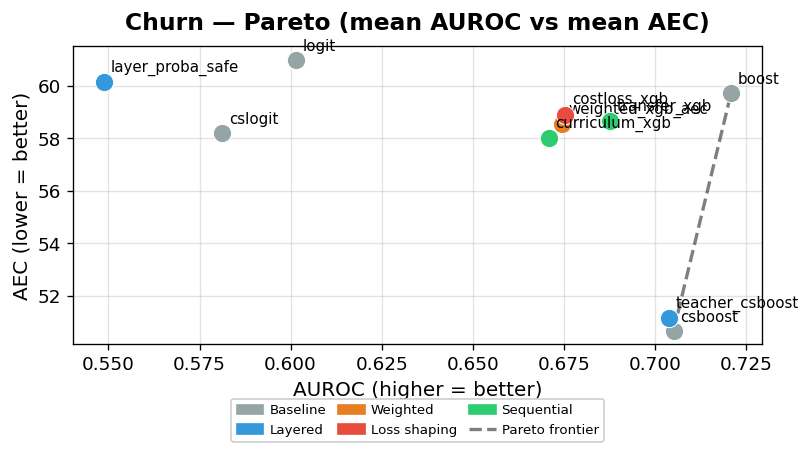

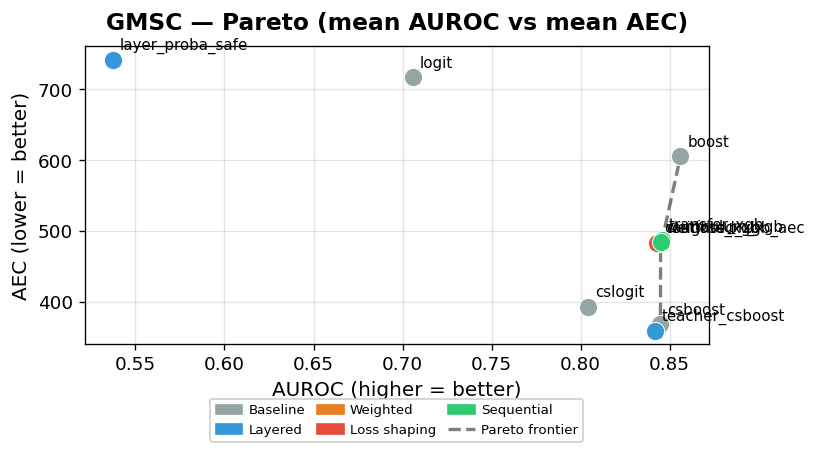

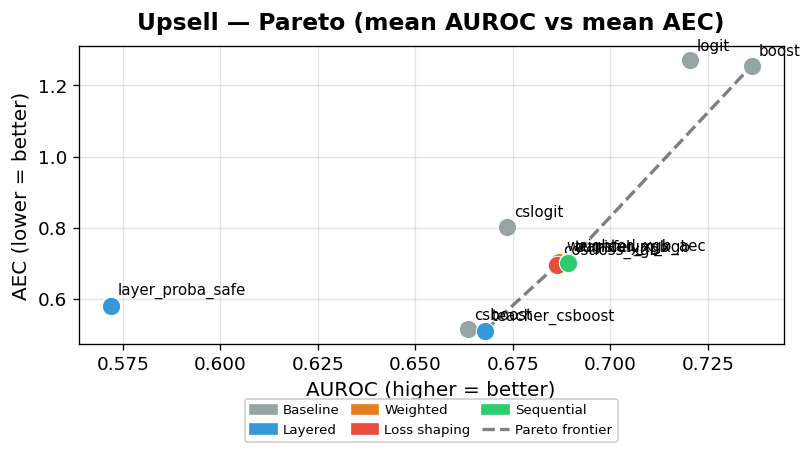

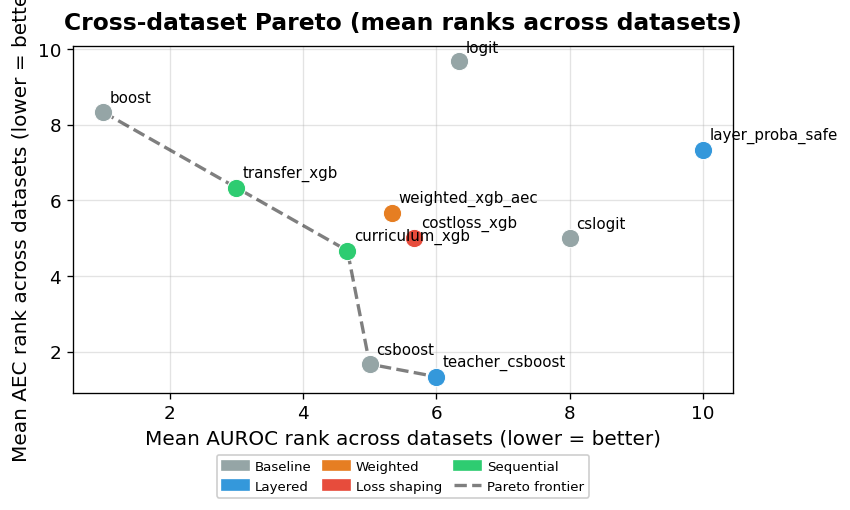

In [6]:
SAVE_KW = dict(dpi=plt.rcParams.get('savefig.dpi', REPORT_SAVEFIG_DPI), bbox_inches='tight')

# One PNG per dataset (Pareto frontier = dashed)
for ds_name, df in all_summaries.items():
    fig, ax = plt.subplots(figsize=(7.2, 5.2))
    models = [m for m in CANONICAL_ORDER if m in df.index]
    aurocs = np.array([df.loc[m, 'AUROC_mean'] for m in models])
    aecs = np.array([df.loc[m, 'AEC_mean'] for m in models])
    nd = pareto_non_dominated_mask(aurocs, aecs)
    for m in models:
        grp = GROUP_LABELS.get(m, 'Other')
        color = GROUP_COLORS.get(grp, 'gray')
        ax.scatter(df.loc[m, 'AUROC_mean'], df.loc[m, 'AEC_mean'],
                   s=120, c=color, edgecolors='white', linewidth=0.6, zorder=3)
        ax.annotate(m, (df.loc[m, 'AUROC_mean'], df.loc[m, 'AEC_mean']),
                    fontsize=9, ha='left', va='bottom', xytext=(4, 4),
                    textcoords='offset points')
    fr_au, fr_ae = aurocs[nd], aecs[nd]
    if len(fr_au) >= 2:
        order = np.argsort(fr_au)
        ax.plot(fr_au[order], fr_ae[order], 'k--', alpha=0.5, linewidth=2.0, zorder=2)

    ax.set_xlabel('AUROC (higher = better)', fontsize=12)
    ax.set_ylabel('AEC (lower = better)', fontsize=12)
    ax.set_title('%s — Pareto (mean AUROC vs mean AEC)' % ds_name, fontsize=14, fontweight='bold', pad=10)
    ax.grid(alpha=0.35)
    handles = [mpatches.Patch(color=c, label=g) for g, c in GROUP_COLORS.items()]
    if len(fr_au) >= 2:
        handles.append(plt.Line2D([0], [0], color='k', linestyle='--', lw=2, alpha=0.5, label='Pareto frontier'))
    _ncol = min(3, max(1, len(handles)))
    ax.legend(
        handles=handles, fontsize=8, loc='upper center', bbox_to_anchor=(0.5, -0.16),
        ncol=_ncol, frameon=True, framealpha=0.95, columnspacing=0.9, handletextpad=0.45,
    )
    plt.tight_layout(rect=[0.02, 0.18, 0.98, 0.98])
    slug = ds_name.lower().replace(' ', '_')
    plt.savefig('pareto_aec_auroc_%s.png' % slug, **SAVE_KW)
    plt.show()

# Cross-dataset summary (separate PNG)
models_agg = [m for m in common_models]
if len(models_agg) >= 2:
    rank_aec = M_aec[models_agg].rank(axis=1, ascending=True)
    rank_auroc = M_auroc[models_agg].rank(axis=1, ascending=False)
    mean_r_aec = rank_aec.mean(axis=0).values
    mean_r_auroc = rank_auroc.mean(axis=0).values
    fig, ax = plt.subplots(figsize=(7.5, 5.8))
    nd = pareto_non_dominated_mask_minimize_both(mean_r_auroc, mean_r_aec)
    for i, m in enumerate(models_agg):
        grp = GROUP_LABELS.get(m, 'Other')
        color = GROUP_COLORS.get(grp, 'gray')
        ax.scatter(mean_r_auroc[i], mean_r_aec[i], s=120, c=color, edgecolors='white', linewidth=0.6, zorder=3)
        ax.annotate(m, (mean_r_auroc[i], mean_r_aec[i]), fontsize=9, ha='left', va='bottom',
                    xytext=(4, 4), textcoords='offset points')
    fr_x, fr_y = mean_r_auroc[nd], mean_r_aec[nd]
    if len(fr_x) >= 2:
        order = np.argsort(fr_x)
        ax.plot(fr_x[order], fr_y[order], 'k--', alpha=0.5, linewidth=2.0, zorder=2)
    ax.set_xlabel('Mean AUROC rank across datasets (lower = better)', fontsize=12)
    ax.set_ylabel('Mean AEC rank across datasets (lower = better)', fontsize=12)
    ax.set_title('Cross-dataset Pareto (mean ranks across datasets)', fontsize=14, fontweight='bold', pad=10)
    ax.grid(alpha=0.35)
    h2 = [mpatches.Patch(color=c, label=g) for g, c in GROUP_COLORS.items()]
    if len(fr_x) >= 2:
        h2.append(plt.Line2D([0], [0], color='k', linestyle='--', lw=2, alpha=0.5, label='Pareto frontier'))
    _ncol2 = min(3, max(1, len(h2)))
    ax.legend(
        handles=h2, fontsize=8, loc='upper center', bbox_to_anchor=(0.5, -0.16),
        ncol=_ncol2, frameon=True, framealpha=0.95, columnspacing=0.9, handletextpad=0.45,
    )
    plt.tight_layout(rect=[0.02, 0.18, 0.98, 0.98])
    plt.savefig('pareto_aec_auroc_cross_dataset.png', **SAVE_KW)
    plt.show()
else:
    print('Cross-dataset Pareto skipped: fewer than 2 models in common_models.')


---
## 4. Rank analysis


  Average ranks — AEC (lower is better)


,Avg Rank
Model,
teacher_csboost,1.33
csboost,1.67
curriculum_xgb,4.67
cslogit,5.00
costloss_xgb,5.00
weighted_xgb_aec,5.67
transfer_xgb,6.33
layer_proba_safe,7.33
boost,8.33


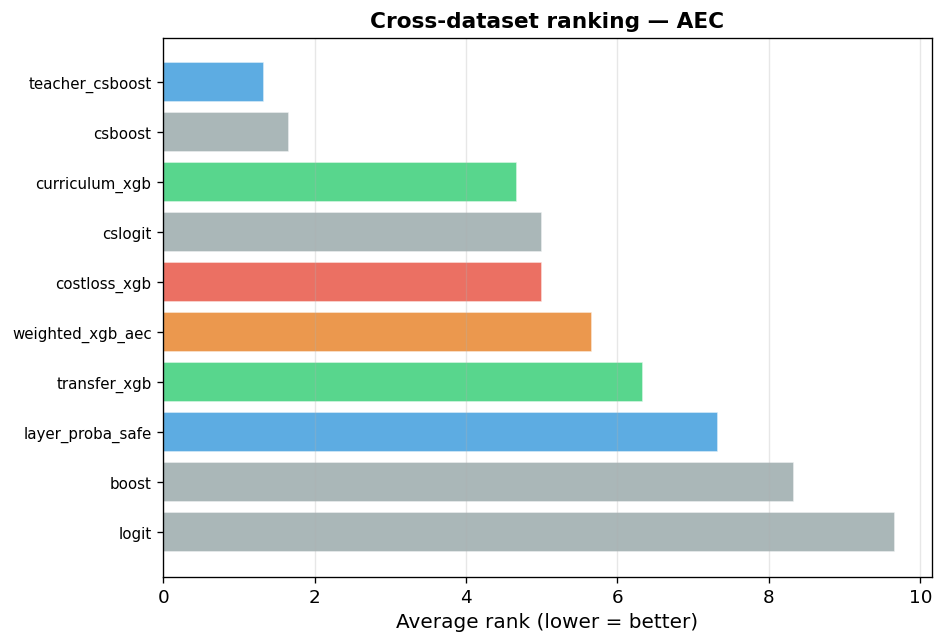


  Average ranks — AUROC (higher is better)


,Avg Rank
Model,
boost,1.00
transfer_xgb,3.00
curriculum_xgb,4.67
csboost,5.00
weighted_xgb_aec,5.33
costloss_xgb,5.67
teacher_csboost,6.00
logit,6.33
cslogit,8.00


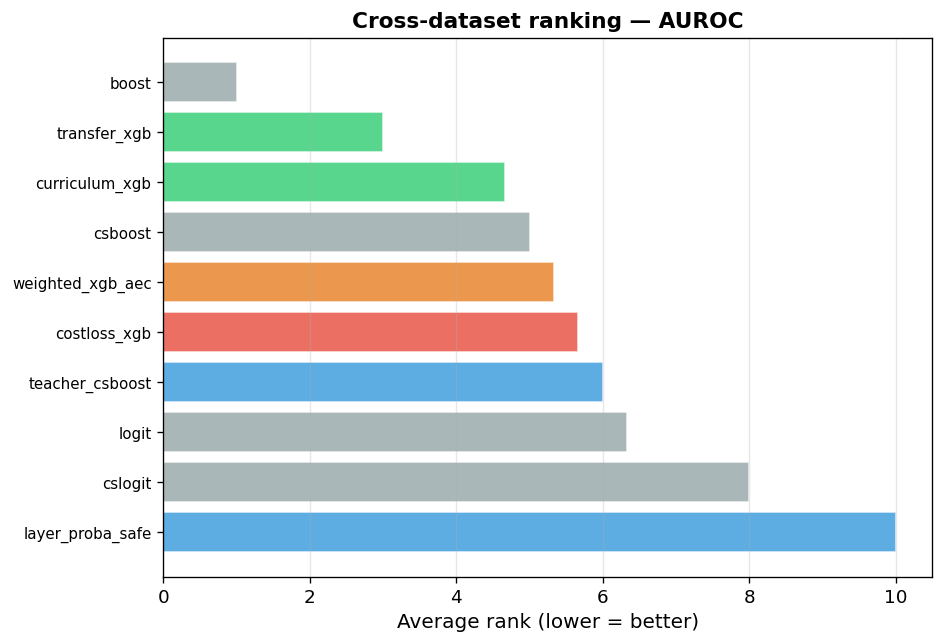

In [7]:
def compute_ranks(metric_df, ascending=True):
    """Rank models per dataset. Returns rank table and average ranks."""
    ranks = metric_df.rank(axis=1, method='average', ascending=ascending)
    avg_ranks = ranks.mean(axis=0).sort_values()
    return ranks, avg_ranks

for metric_name, metric_df, asc in [('AEC', M_aec, True), ('AUROC', M_auroc, False)]:
    ranks, avg_ranks = compute_ranks(metric_df, ascending=asc)

    print(f'\n{"=" * 50}')
    print(f'  Average ranks — {metric_name} ({"lower" if asc else "higher"} is better)')
    print(f'{"=" * 50}')
    display(avg_ranks.rename('Avg Rank').to_frame().round(2))

    fig, ax = plt.subplots(figsize=(8, 0.4 * len(avg_ranks) + 1.5))
    colors = [GROUP_COLORS.get(GROUP_LABELS.get(m, 'Other'), 'gray') for m in avg_ranks.index]
    ax.barh(range(len(avg_ranks)), avg_ranks.values, color=colors, alpha=0.8, edgecolor='white')
    ax.set_yticks(range(len(avg_ranks)))
    ax.set_yticklabels(avg_ranks.index, fontsize=9)
    ax.set_xlabel('Average rank (lower = better)')
    ax.set_title(f'Cross-dataset ranking — {metric_name}', fontsize=13, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'rank_barplot_{metric_name.lower()}.png', dpi=200, bbox_inches='tight')
    plt.show()

---
## 5. Win-rate heatmaps

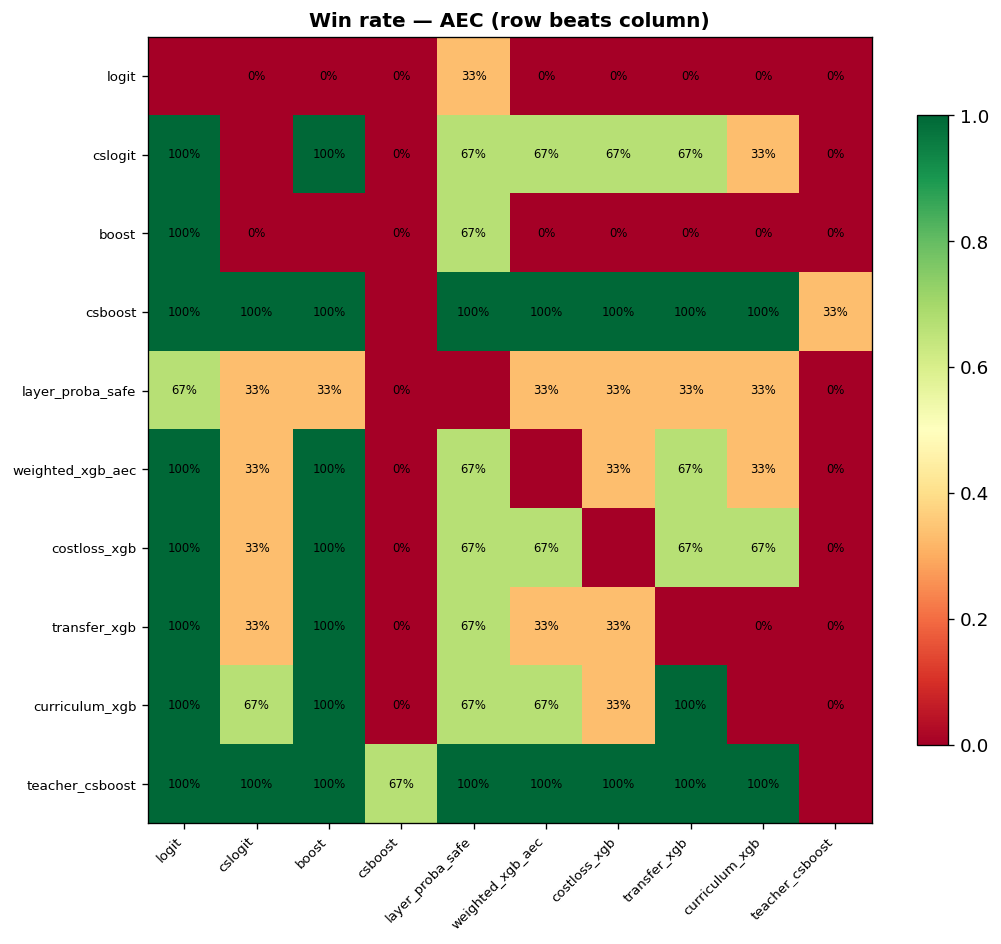

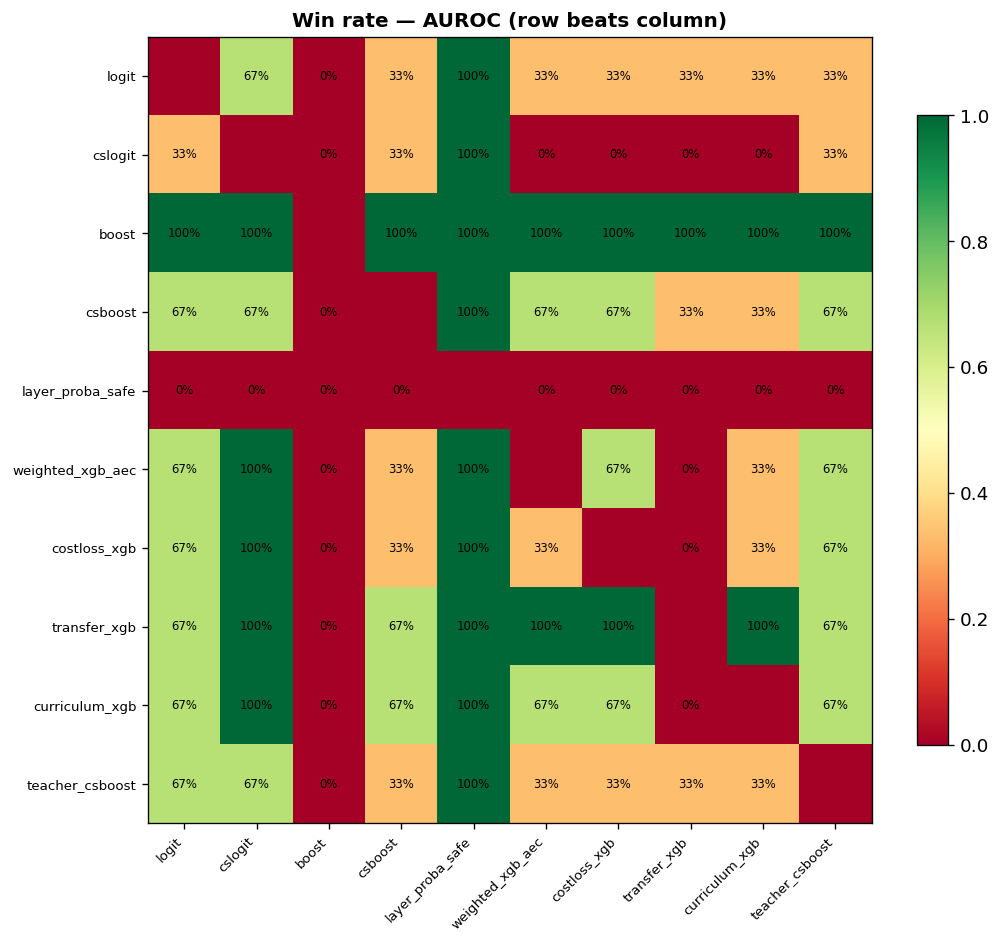

In [8]:
for metric_name, metric_df, asc in [('AEC', M_aec, True), ('AUROC', M_auroc, False)]:
    models = common_models
    n = len(models)
    win_matrix = np.zeros((n, n))

    for ds in metric_df.index:
        vals = metric_df.loc[ds, models].values
        for i in range(n):
            for j in range(n):
                if i == j:
                    continue
                if asc:
                    win_matrix[i, j] += (vals[i] < vals[j])
                else:
                    win_matrix[i, j] += (vals[i] > vals[j])

    win_rate = win_matrix / len(metric_df)

    fig, ax = plt.subplots(figsize=(0.7 * n + 2, 0.6 * n + 2))
    im = ax.imshow(win_rate, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(n))
    ax.set_xticklabels(models, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(n))
    ax.set_yticklabels(models, fontsize=8)
    for i in range(n):
        for j in range(n):
            if i != j:
                ax.text(j, i, f'{win_rate[i, j]:.0%}', ha='center', va='center', fontsize=7)
    ax.set_title(f'Win rate — {metric_name} (row beats column)', fontsize=12, fontweight='bold')
    fig.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    plt.savefig(f'winrate_{metric_name.lower()}.png', dpi=200, bbox_inches='tight')
    plt.show()

---
## 6. Friedman + Nemenyi significance testing (cross-dataset)


  Friedman test — AEC
  #datasets=3, #models=10
  chi² = 20.5273, p = 0.014923
  Nemenyi CD (α=0.05) = 7.8208


,Avg Rank
Model,
teacher_csboost,1.333
csboost,1.667
curriculum_xgb,4.667
cslogit,5.000
costloss_xgb,5.000
weighted_xgb_aec,5.667
transfer_xgb,6.333
layer_proba_safe,7.333
boost,8.333



Significant pairs (2):


,Model A,Model B,|Rank diff|,Significant
0,teacher_csboost,logit,8.3333,True
1,csboost,logit,8.0000,True


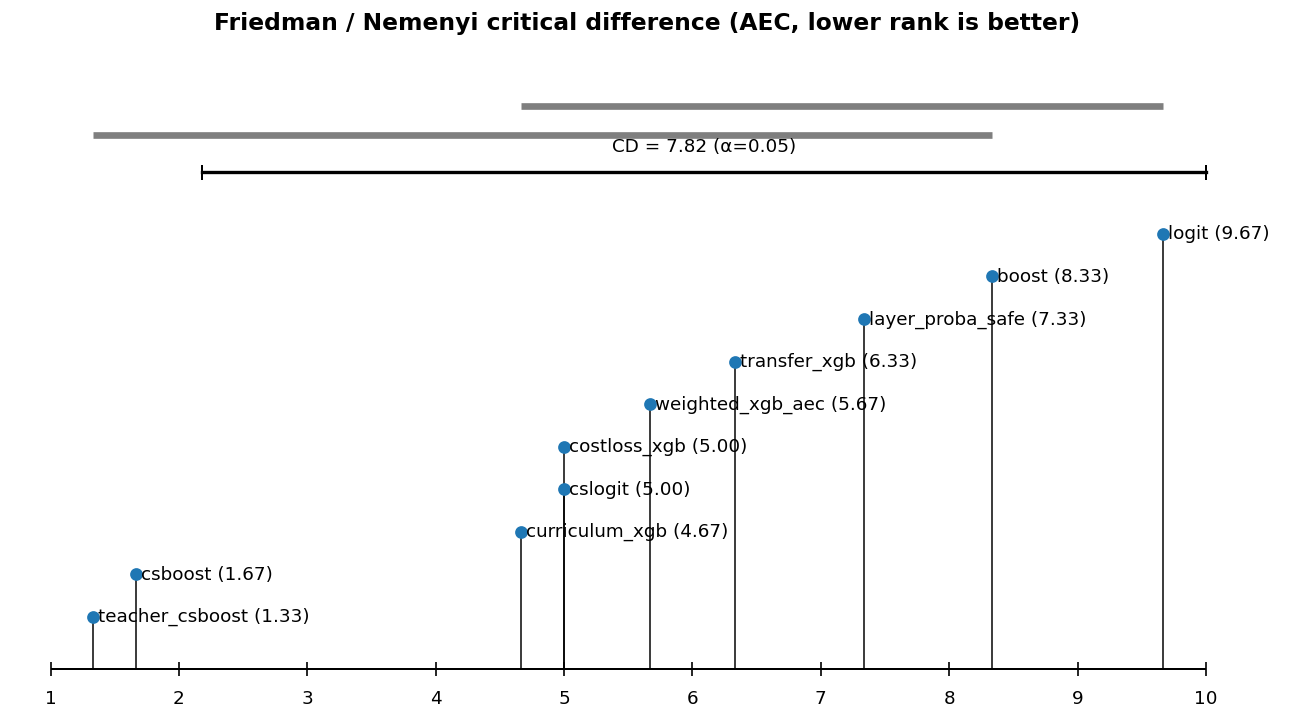


  Friedman test — AUROC
  #datasets=3, #models=10
  chi² = 17.9818, p = 0.035385
  Nemenyi CD (α=0.05) = 7.8208


,Avg Rank
Model,
boost,1.000
transfer_xgb,3.000
curriculum_xgb,4.667
csboost,5.000
weighted_xgb_aec,5.333
costloss_xgb,5.667
teacher_csboost,6.000
logit,6.333
cslogit,8.000



Significant pairs (1):


,Model A,Model B,|Rank diff|,Significant
0,boost,layer_proba_safe,9.0,True


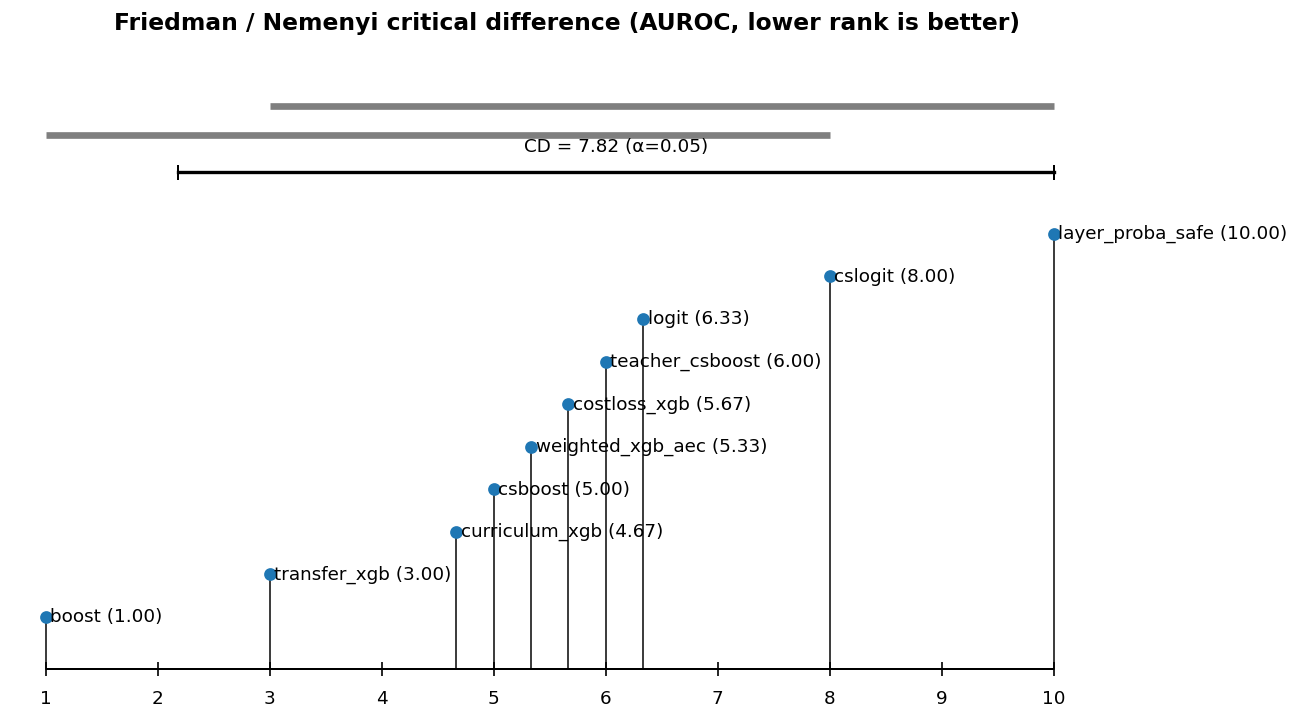

In [9]:
from itertools import combinations


def nemenyi_cd(n_models, n_blocks, alpha=0.05):
    q_alpha = studentized_range.ppf(1 - alpha, n_models, np.inf) / np.sqrt(2)
    return q_alpha * np.sqrt(n_models * (n_models + 1) / (6.0 * n_blocks))


def maximal_nonsignificant_cliques(avg_ranks, cd):
    model_names = list(avg_ranks.index)
    rank_map = avg_ranks.to_dict()
    all_groups = []

    for r in range(2, len(model_names) + 1):
        for subset in combinations(model_names, r):
            if all(abs(rank_map[a] - rank_map[b]) <= cd + 1e-12
                   for i, a in enumerate(subset) for b in subset[i + 1:]):
                all_groups.append(subset)

    maximal_groups = []
    for group in all_groups:
        if not any(set(group) < set(other) for other in all_groups):
            maximal_groups.append(group)

    deduped = []
    seen = set()
    for group in maximal_groups:
        if group not in seen:
            deduped.append(group)
            seen.add(group)

    deduped.sort(
        key=lambda group: (
            -(max(rank_map[m] for m in group) - min(rank_map[m] for m in group)),
            -len(group),
            tuple(group),
        )
    )
    return deduped


def plot_cd_diagram(avg_ranks, cd, metric='AEC', alpha=0.05):
    """Demšar-style CD diagram (same structure as churn/gmsc/upsell notebooks)."""
    avg_ranks = avg_ranks.sort_values()
    models = list(avg_ranks.index)
    ranks = avg_ranks.values
    n_models = len(models)

    fig_height = 2.4 + 0.38 * n_models
    fig, ax = plt.subplots(figsize=(11, fig_height))

    x_min, x_max = 1, n_models
    axis_y = 0.2
    ax.hlines(axis_y, x_min, x_max, color='black', linewidth=1.2)
    for tick in range(1, n_models + 1):
        ax.vlines(tick, axis_y - 0.03, axis_y + 0.03, color='black', linewidth=1.0)
        ax.text(tick, axis_y - 0.09, '%d' % tick, ha='center', va='top', fontsize=11)

    for idx, (model, rank) in enumerate(zip(models, ranks)):
        y = 0.42 + idx * 0.18
        ax.plot([rank, rank], [axis_y, y], color='black', linewidth=0.9)
        ax.scatter(rank, y, s=44, color='tab:blue', zorder=3)
        ax.text(rank + 0.04, y, '%s (%.2f)' % (model, rank), va='center', ha='left', fontsize=11)

    cd_y = 0.42 + n_models * 0.18 + 0.08
    ax.plot([x_max - cd, x_max], [cd_y, cd_y], color='black', linewidth=2.0)
    ax.vlines([x_max - cd, x_max], cd_y - 0.03, cd_y + 0.03, color='black', linewidth=1.2)
    ax.text(
        x_max - cd / 2, cd_y + 0.07, 'CD = %.2f (α=%.2f)' % (cd, alpha),
        ha='center', va='bottom', fontsize=11,
    )

    line_y = cd_y + 0.16
    used_spans = set()
    for clique in maximal_nonsignificant_cliques(avg_ranks, cd):
        clique_ranks = [avg_ranks[m] for m in clique]
        span = (round(min(clique_ranks), 6), round(max(clique_ranks), 6))
        if span in used_spans:
            continue
        used_spans.add(span)
        ax.hlines(line_y, min(clique_ranks), max(clique_ranks), color='tab:gray', linewidth=4)
        line_y += 0.12

    ax.set_xlim(0.7, n_models + 0.6)
    ax.set_ylim(0.0, line_y + 0.12)
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_title(
        'Friedman / Nemenyi critical difference (%s, lower rank is better)' % metric,
        fontsize=14, fontweight='bold', pad=12,
    )
    for spine in ['left', 'right', 'top', 'bottom']:
        ax.spines[spine].set_visible(False)
    plt.tight_layout()
    return fig


for metric_name, metric_df, asc in [('AEC', M_aec, True), ('AUROC', M_auroc, False)]:
    ranks, avg_ranks = compute_ranks(metric_df, ascending=asc)
    n_models = len(common_models)
    n_blocks = len(metric_df)

    samples = [metric_df[m].values for m in common_models]
    stat, p_val = friedmanchisquare(*samples)
    cd = nemenyi_cd(n_models, n_blocks, ALPHA)

    print(f'\n{"=" * 60}')
    print(f'  Friedman test — {metric_name}')
    print(f'  #datasets={n_blocks}, #models={n_models}')
    print(f'  chi² = {stat:.4f}, p = {p_val:.6f}')
    print(f'  Nemenyi CD (α={ALPHA}) = {cd:.4f}')
    print(f'{"=" * 60}')

    display(avg_ranks.rename('Avg Rank').to_frame().round(3))

    pair_rows = []
    for i, mi in enumerate(avg_ranks.index):
        for j, mj in enumerate(avg_ranks.index):
            if i >= j:
                continue
            d = abs(avg_ranks[mi] - avg_ranks[mj])
            pair_rows.append({'Model A': mi, 'Model B': mj,
                              '|Rank diff|': round(d, 4),
                              'Significant': d > cd})
    pairs_df = pd.DataFrame(pair_rows).sort_values('|Rank diff|', ascending=False)
    sig_pairs = pairs_df[pairs_df['Significant']]
    if len(sig_pairs):
        print(f'\nSignificant pairs ({len(sig_pairs)}):')
        display(sig_pairs.reset_index(drop=True))
    else:
        print('\nNo significant pairwise differences at α =', ALPHA)

    fig = plot_cd_diagram(avg_ranks, cd, metric=metric_name, alpha=ALPHA)
    plt.savefig(
        'cd_diagram_%s.png' % metric_name.lower(),
        dpi=plt.rcParams.get('savefig.dpi', REPORT_SAVEFIG_DPI),
        bbox_inches='tight',
    )
    plt.show()

---
## 7. Per-dataset model comparison (boxplots from summary stats)

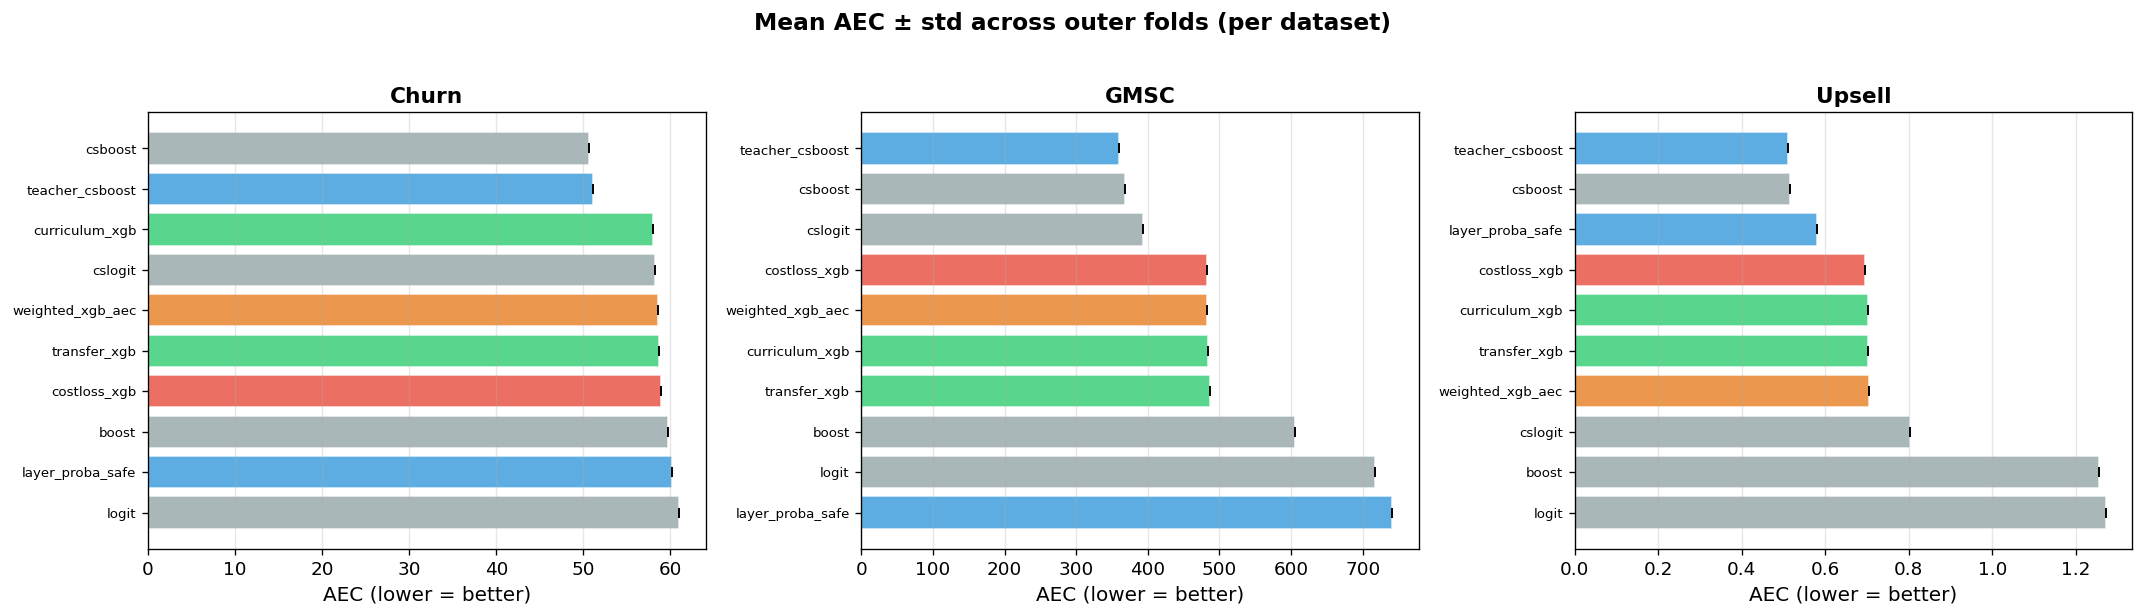

In [10]:
n_ds = len(all_summaries)
fig, axes = plt.subplots(1, n_ds, figsize=(6 * n_ds, 5), sharey=False)
if n_ds == 1:
    axes = [axes]

for ax, (ds_name, df) in zip(axes, all_summaries.items()):
    models = [m for m in CANONICAL_ORDER if m in df.index]
    aec_vals = df.loc[models, 'AEC_mean'].values
    aec_std = df.loc[models, 'AEC_std'].values if 'AEC_std' in df.columns else np.zeros(len(models))
    colors = [GROUP_COLORS.get(GROUP_LABELS.get(m, 'Other'), 'gray') for m in models]

    sorted_idx = np.argsort(aec_vals)
    ax.barh(range(len(models)), aec_vals[sorted_idx], xerr=aec_std[sorted_idx],
            color=[colors[i] for i in sorted_idx], alpha=0.8, edgecolor='white', capsize=3)
    ax.set_yticks(range(len(models)))
    ax.set_yticklabels([models[i] for i in sorted_idx], fontsize=8)
    ax.set_xlabel('AEC (lower = better)')
    ax.set_title(ds_name, fontsize=13, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.invert_yaxis()

fig.suptitle('Mean AEC ± std across outer folds (per dataset)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('aec_per_dataset.png', dpi=200, bbox_inches='tight')
plt.show()

---
## 8. Rank divergence: AEC ranking vs AUROC ranking

Rank divergence: models that rank differently on AEC vs AUROC


,AEC rank,AUROC rank,Divergence
Model,,,
teacher_csboost,1.33,6.00,4.67
csboost,1.67,5.00,3.33
curriculum_xgb,4.67,4.67,0.00
costloss_xgb,5.00,5.67,0.67
cslogit,5.00,8.00,3.00
weighted_xgb_aec,5.67,5.33,0.33
transfer_xgb,6.33,3.00,3.33
layer_proba_safe,7.33,10.00,2.67
boost,8.33,1.00,7.33


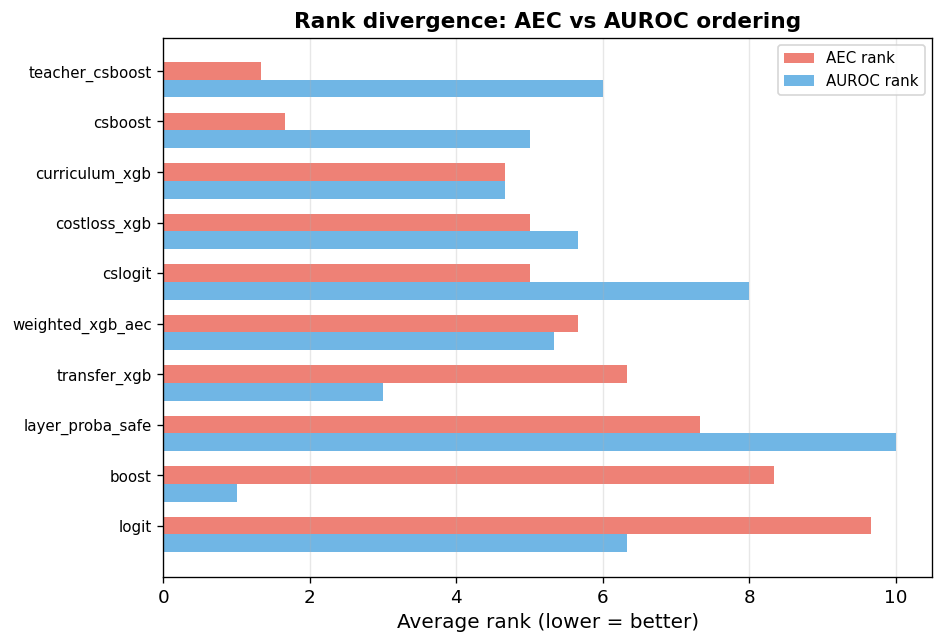

In [11]:
_, aec_ranks = compute_ranks(M_aec, ascending=True)
_, auroc_ranks = compute_ranks(M_auroc, ascending=False)

rank_comparison = pd.DataFrame({
    'AEC rank': aec_ranks,
    'AUROC rank': auroc_ranks,
    'Divergence': (aec_ranks - auroc_ranks).abs()
}).sort_values('AEC rank')

print('Rank divergence: models that rank differently on AEC vs AUROC')
display(rank_comparison.round(2))

fig, ax = plt.subplots(figsize=(8, 0.4 * len(rank_comparison) + 1.5))
y = range(len(rank_comparison))
ax.barh(y, rank_comparison['AEC rank'], height=0.35, label='AEC rank',
        color='#e74c3c', alpha=0.7, align='edge')
ax.barh([yi + 0.35 for yi in y], rank_comparison['AUROC rank'], height=0.35,
        label='AUROC rank', color='#3498db', alpha=0.7, align='edge')
ax.set_yticks([yi + 0.175 for yi in y])
ax.set_yticklabels(rank_comparison.index, fontsize=9)
ax.set_xlabel('Average rank (lower = better)')
ax.set_title('Rank divergence: AEC vs AUROC ordering', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('rank_divergence.png', dpi=200, bbox_inches='tight')
plt.show()

---
## 9. Grouped comparison: baselines vs proposed (per dataset)

In [12]:
for ds_name, df in all_summaries.items():
    models = [m for m in CANONICAL_ORDER if m in df.index]
    baseline_aec = df.loc[[m for m in models if m in BASELINES], 'AEC_mean']
    proposed_aec = df.loc[[m for m in models if m in PROPOSED], 'AEC_mean']

    best_baseline = baseline_aec.idxmin()
    best_proposed = proposed_aec.idxmin()

    improvement = (baseline_aec.min() - proposed_aec.min()) / baseline_aec.min() * 100

    print(f'\n{ds_name}:')
    print(f'  Best baseline: {best_baseline} (AEC = {baseline_aec.min():.4f})')
    print(f'  Best proposed: {best_proposed} (AEC = {proposed_aec.min():.4f})')
    print(f'  Improvement: {improvement:+.2f}%')

    n_proposed_beating_best_baseline = (proposed_aec < baseline_aec.min()).sum()
    print(f'  Proposed models beating best baseline: {n_proposed_beating_best_baseline}/{len(proposed_aec)}')


Churn:
  Best baseline: csboost (AEC = 50.6739)
  Best proposed: teacher_csboost (AEC = 51.1578)
  Improvement: -0.95%
  Proposed models beating best baseline: 0/6

GMSC:
  Best baseline: csboost (AEC = 368.4347)
  Best proposed: teacher_csboost (AEC = 359.1374)
  Improvement: +2.52%
  Proposed models beating best baseline: 1/6

Upsell:
  Best baseline: csboost (AEC = 0.5144)
  Best proposed: teacher_csboost (AEC = 0.5098)
  Improvement: +0.89%
  Proposed models beating best baseline: 1/6


---
## 10. Export summary tables to CSV

In [13]:
out_dir = REPO_ROOT / 'results'
out_dir.mkdir(exist_ok=True)

M_aec.to_csv(out_dir / 'cross_dataset_aec.csv')
M_auroc.to_csv(out_dir / 'cross_dataset_auroc.csv')

for ds_name, df in all_summaries.items():
    slug = ds_name.lower().replace(' ', '_')
    df.to_csv(out_dir / f'summary_{slug}.csv')

print(f'Exported to {out_dir}/')
for f in sorted(out_dir.glob('*.csv')):
    print(f'  {f.name}')

Exported to /Users/lea/final cost sensitive /results/
  cross_dataset_aec.csv
  cross_dataset_auroc.csv
  summary_churn.csv
  summary_gmsc.csv
  summary_upsell.csv
